Beta's value is 2.6622780026990555e-20


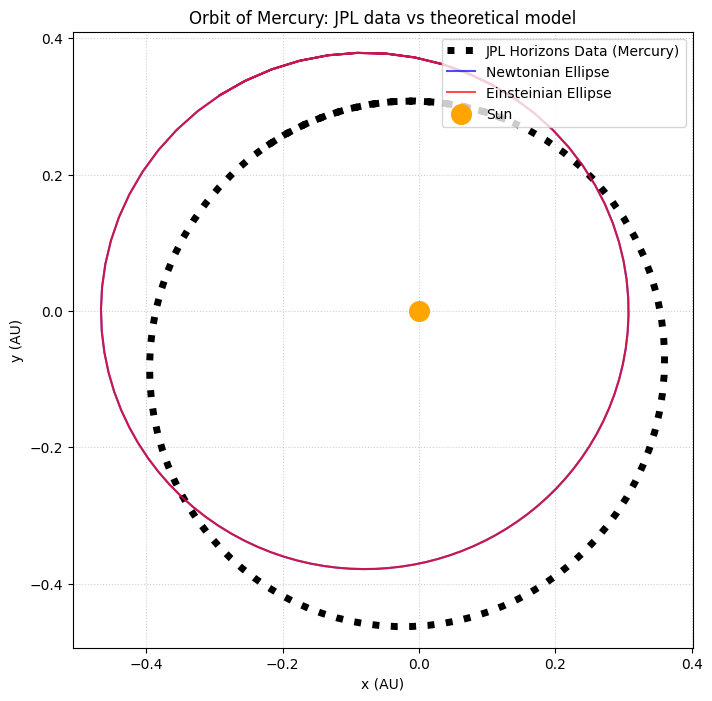

In [3]:
!pip install astroquery
import numpy as np
import matplotlib.pyplot as plt
from astroquery.jplhorizons import Horizons

# Constants
c = 3*10**8
G_M_SUN = 0.0002959122

# 1. Parameters to load data from JPL
# Mercury's ID: 199 (Jupiter's is 599)
# Centre: @sun (heliocentric coordinates)

# Time range: Mercury's orbital period is around ~ 88 days, we load 100 days.
obj = Horizons(id='199', location='@sun',
               epochs={'start': '2023-01-01', 'stop': '2023-04-10', 'step': '1d'})

# Obtain the position vectors (x, y, z)
vectors = obj.vectors()

# Extract coordinates in astronomical units (AU)
x_mercury = vectors['x']
y_mercury = vectors['y']

# 2. Estimation of parameters for theoretical model
# For Mercury: a ≈ 0.387 AU, e ≈ 0.2056
e_estimate = 0.2056
p_estimate = 0.3705

# Compute the actual beta and a false one for later
betareal = (3*G_M_SUN)/(p_estimate*c**2)
betafalse = 4/100
print(f"Beta's value is {betareal}")


# Construct the theoretical model
phi = np.arctan2(y_mercury, x_mercury)

# Newtonian model
r_pred = p_estimate / (1 + e_estimate * np.cos(phi))
x_pred = r_pred * np.cos(phi)
y_pred = r_pred * np.sin(phi)

#Einstein's model
u_einstein = (1+e_estimate*np.cos(phi))/p_estimate + betareal*(1+(e_estimate**2)/2 + e_estimate*phi*np.sin(phi)- np.cos(2*phi)*(e_estimate**2)/6)/p_estimate
r_einstein = 1/(u_einstein)
x_einstein = r_einstein * np.cos(phi)
y_einstein = r_einstein * np.sin(phi)


# 3. Comparative plot
plt.figure(figsize=(8, 8))

# Plot real data from JPL
plt.plot(x_mercury, y_mercury, 'k:', markersize=2, lw=5,label='JPL Horizons Data (Mercury)')

# Plot theoretical predictions from Newton and Einstein
plt.plot(x_pred, y_pred, 'b', alpha=0.7, label=f'Newtonian Ellipse')
plt.plot(x_einstein, y_einstein, 'r', alpha=0.7, label=f'Einsteinian Ellipse')

# Plot the Sun
plt.scatter([0], [0], color='orange', s=200, label='Sun', zorder=5)

plt.xlabel('x (AU)')
plt.ylabel('y (AU)')
plt.title('Orbit of Mercury: JPL data vs theoretical model')
plt.legend(loc = 'upper right')
plt.axis('equal')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

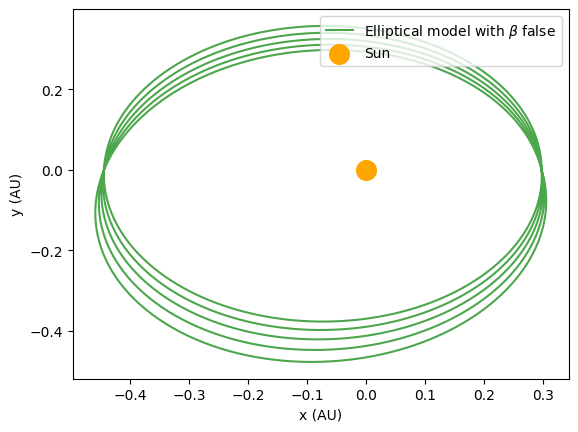

In [2]:
# Let us use the false beta now, to see what happens
phi_false = np.linspace(0, 10*np.pi, 1000)
u_einstein_false = (1+e_estimate*np.cos(phi_false))/p_estimate + betafalse*(1+(e_estimate**2)/2 + e_estimate*phi_false*np.sin(phi_false)- np.cos(2*phi_false)*(e_estimate**2)/6)/p_estimate
r_einstein_false = 1/(u_einstein_false)
x_einstein_false = r_einstein_false * np.cos(phi_false)
y_einstein_false = r_einstein_false * np.sin(phi_false)

# Plot Einstein's prediction with false beta
plt.plot(x_einstein_false, y_einstein_false, 'g', alpha=0.7, label=f'Elliptical model with $\\beta$ false')
plt.scatter([0], [0], color='orange', s=200, label='Sun', zorder=5)
plt.xlabel('x (AU)')
plt.ylabel('y (AU)')
plt.legend(loc='upper right')
plt.show()

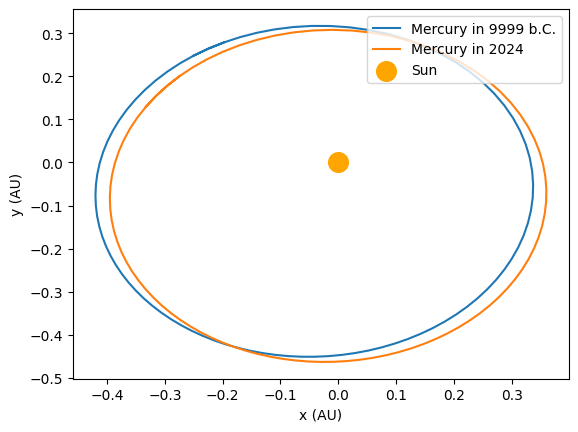

In [4]:
# "Ancient" orbit (9999 b.C.)
obj_old = Horizons(id='199', location='@sun',
                   epochs={'start': 'BC 9990-01-01', 'stop': 'BC 9990-04-01', 'step': '1d'})
vec_old = obj_old.vectors()

# Modern orbit (2024)
obj_new = Horizons(id='199', location='@sun',
                   epochs={'start': '2024-01-01', 'stop': '2024-04-01', 'step': '1d'})
vec_new = obj_new.vectors()

# When plotting both orbits, we can observe the perihelion precession
plt.plot(vec_old['x'], vec_old['y'], label='Mercury in 9999 b.C.')
plt.plot(vec_new['x'], vec_new['y'], label='Mercury in 2024')
plt.scatter([0], [0], color='orange', s=200, label='Sun', zorder=5)
plt.xlabel('x (AU)')
plt.ylabel('y (AU)')
plt.legend(loc= 'upper right')
plt.show()